In [ ]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 10.4 MB/s eta 0:00:00


#A. IMPORT LIBRARY

In [43]:
import optuna
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holidays
import joblib
import os
import json
import time
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#B. DATA UNDERSTANDING

1. Collect Initial Data

In [3]:
df = pd.read_excel('/content/drive/MyDrive/skripsi/prediksi pasien/raw_data.xlsx', header=None)

In [4]:
df.columns = [
    'no_register',
    'no_rekam_medis',
    'jenis_kelamin',
    'umur',
    'status_umur',
    'tgl_masuk',
    'tgl_keluar',
    'kd_penyakit',
    'nama_penyakit',
    'tb_ralan',
    'bb_ralan',
    'tb_ranap',
    'bb_ranap'
]

df.head()

,no_register,no_rekam_medis,jenis_kelamin,umur,status_umur,tgl_masuk,tgl_keluar,kd_penyakit,nama_penyakit,tb_ralan,bb_ralan,tb_ranap,bb_ranap
0,2023/01/01/000002,256521,P,61,Th,2023-01-01,2023-01-02,K30,Dyspepsia,tb,tb,tt,tb
1,2023/01/01/000003,266521,P,63,Th,2023-01-01,2023-01-04,U07.1,Emergency use of U07.1,NaN,NaN,NaN,NaN
2,2023/01/01/000004,276521,L,62,Th,2023-01-01,2023-01-06,A16.2,"Tuberculosis of lung, without mention of bacte...",NaN,NaN,NaN,NaN
3,2023/01/01/000005,774213,P,21,Th,2023-01-01,2023-01-03,M32.9,"Systemic lupus erythematosus, unspecified",NaN,NaN,NaN,NaN
4,2023/01/01/000006,286521,P,68,Th,2023-01-02,2023-01-04,I63.9,"Cerebral infarction, unspecified",NaN,NaN,NaN,NaN


2. Describe Data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29459 entries, 0 to 29458
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   no_register     29459 non-null  object        
 1   no_rekam_medis  29459 non-null  int64         
 2   jenis_kelamin   29459 non-null  object        
 3   umur            29459 non-null  int64         
 4   status_umur     29459 non-null  object        
 5   tgl_masuk       29459 non-null  datetime64[ns]
 6   tgl_keluar      29459 non-null  datetime64[ns]
 7   kd_penyakit     29456 non-null  object        
 8   nama_penyakit   29456 non-null  object        
 9   tb_ralan        14998 non-null  object        
 10  bb_ralan        15801 non-null  object        
 11  tb_ranap        11352 non-null  object        
 12  bb_ranap        12662 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(9)
memory usage: 2.9+ MB


3. Explore Data

In [6]:
df.describe()

,no_rekam_medis,umur,tgl_masuk,tgl_keluar
count,29459.000000,29459.000000,29459,29459
mean,499909.482196,47.595811,2024-08-25 14:25:53.209545472,2024-08-28 14:14:41.577786112
min,26.000000,0.000000,2023-01-01 00:00:00,2023-01-02 00:00:00
25%,249323.000000,31.000000,2023-12-06 00:00:00,2023-12-08 00:00:00
50%,499824.000000,51.000000,2024-08-25 00:00:00,2024-08-28 00:00:00
75%,751476.000000,64.000000,2025-06-01 00:00:00,2025-06-05 00:00:00
max,999921.000000,2019.000000,2026-04-01 00:00:00,2026-04-06 00:00:00
std,288883.041284,35.474310,NaN,NaN


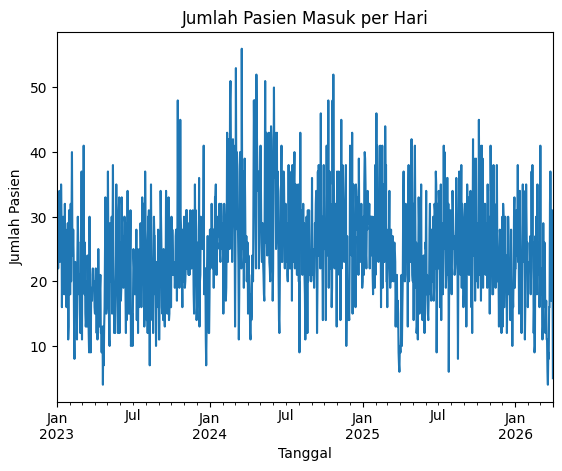

In [7]:
# Hitung jumlah pasien per hari
daily = df.groupby('tgl_masuk').size()

# Plot
plt.figure()
daily.plot()
plt.title('Jumlah Pasien Masuk per Hari')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Pasien')
plt.show()

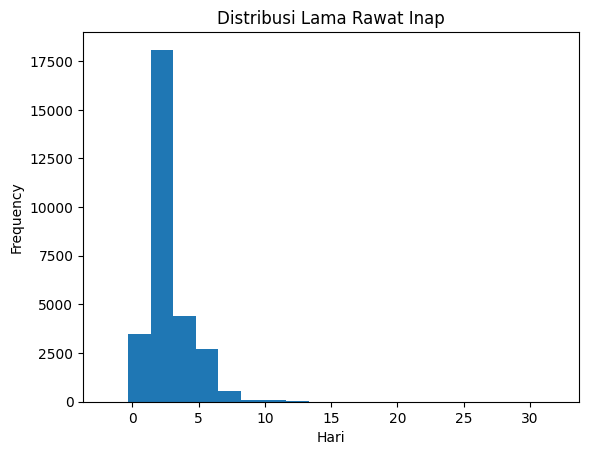

In [8]:
df['tgl_keluar'] = pd.to_datetime(df['tgl_keluar'])

df['lama_rawat'] = (df['tgl_keluar'] - df['tgl_masuk']).dt.days

df['lama_rawat'].plot(kind='hist', bins=20)
plt.title('Distribusi Lama Rawat Inap')
plt.xlabel('Hari')
plt.show()

4. Verify Data Quality

In [9]:
df.isnull().sum()

,0
no_register,0
no_rekam_medis,0
jenis_kelamin,0
umur,0
status_umur,0
tgl_masuk,0
tgl_keluar,0
kd_penyakit,3
nama_penyakit,3
tb_ralan,14461


#C. DATA PREPARATION

1. Select Data

In [10]:
df_selected = df[['no_register', 'tgl_masuk', 'tgl_keluar']].copy()

In [11]:
df_selected['tgl_masuk'] = pd.to_datetime(df_selected['tgl_masuk'])
df_selected['tgl_keluar'] = pd.to_datetime(df_selected['tgl_keluar'])

df_selected.head()

,no_register,tgl_masuk,tgl_keluar
0,2023/01/01/000002,2023-01-01,2023-01-02
1,2023/01/01/000003,2023-01-01,2023-01-04
2,2023/01/01/000004,2023-01-01,2023-01-06
3,2023/01/01/000005,2023-01-01,2023-01-03
4,2023/01/01/000006,2023-01-02,2023-01-04


2. Clean Data

In [12]:
df_selected.isnull().sum()

,0
no_register,0
tgl_masuk,0
tgl_keluar,0


In [13]:
df_selected.duplicated(subset=['no_register']).sum()

np.int64(484)

In [14]:
df_selected[
    df_selected.duplicated(keep=False)
].sort_values('no_register')

,no_register,tgl_masuk,tgl_keluar
14,2023/01/01/000023,2023-01-01,2023-01-03
15,2023/01/01/000023,2023-01-01,2023-01-03
22,2023/01/02/000231,2023-01-02,2023-01-06
23,2023/01/02/000231,2023-01-02,2023-01-06
26,2023/01/02/000306,2023-01-02,2023-01-06
...,...,...,...
29227,2026/03/22/000028,2026-03-22,2026-03-24
29248,2026/03/24/000034,2026-03-24,2026-03-27
29249,2026/03/24/000034,2026-03-24,2026-03-27
29446,2026/03/31/000672,2026-04-01,2026-04-03


In [15]:
df_selected = df_selected.drop_duplicates(subset=['no_register'])

In [16]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28975 entries, 0 to 29458
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   no_register  28975 non-null  object        
 1   tgl_masuk    28975 non-null  datetime64[ns]
 2   tgl_keluar   28975 non-null  datetime64[ns]
dtypes: datetime64[ns](2), object(1)
memory usage: 905.5+ KB


In [17]:
df_selected[df_selected['tgl_keluar'] < df_selected['tgl_masuk']]\
.sort_values(by='tgl_masuk')

,no_register,tgl_masuk,tgl_keluar
1640,2023/03/14/000442,2023-03-14,2023-03-13
12426,2024/06/02/000056,2024-06-05,2024-06-03


In [18]:
df_selected = df_selected[df_selected['tgl_keluar'] >= df_selected['tgl_masuk']]

In [19]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28973 entries, 0 to 29458
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   no_register  28973 non-null  object        
 1   tgl_masuk    28973 non-null  datetime64[ns]
 2   tgl_keluar   28973 non-null  datetime64[ns]
dtypes: datetime64[ns](2), object(1)
memory usage: 905.4+ KB


3. Construct Data

In [20]:
df_selected['tanggal'] = df_selected.apply(
    lambda row: pd.date_range(start=row['tgl_masuk'], end=row['tgl_keluar']),
    axis=1
)

df_exploded = df_selected.explode('tanggal')
daily = df_exploded.groupby('tanggal').size().reset_index(name='jumlah_pasien')

daily = daily.sort_values(by='tanggal').reset_index(drop=True)
daily.head(10)

,tanggal,jumlah_pasien
0,2023-01-01,13
1,2023-01-02,37
2,2023-01-03,62
3,2023-01-04,74
4,2023-01-05,86
5,2023-01-06,90
6,2023-01-07,85
7,2023-01-08,78
8,2023-01-09,103
9,2023-01-10,93


In [21]:
daily['is_weekend'] = daily['tanggal'].dt.weekday.isin([5,6]).astype(int)

In [22]:
daily[['tanggal','is_weekend']].head(10)

,tanggal,is_weekend
0,2023-01-01,1
1,2023-01-02,0
2,2023-01-03,0
3,2023-01-04,0
4,2023-01-05,0
5,2023-01-06,0
6,2023-01-07,1
7,2023-01-08,1
8,2023-01-09,0
9,2023-01-10,0


In [25]:
years = range(2023, 2027)

indo_holidays = holidays.Indonesia(years=years)

In [26]:
holiday_df = pd.DataFrame(
    list(indo_holidays.items()),
    columns=['tanggal', 'nama_libur']
)

holiday_df.head(20)

,tanggal,nama_libur
0,2024-01-01,New Year's Day
1,2024-08-17,Independence Day
2,2024-12-25,Christmas Day
3,2024-04-10,Eid al-Fitr
4,2024-04-11,Eid al-Fitr Second Day
5,2024-06-17,Eid al-Adha
6,2024-02-08,Isra' and Mi'raj
7,2024-05-09,Ascension Day
8,2024-07-07,Islamic New Year
9,2024-09-16,Prophet's Birthday


In [27]:
def get_holiday_dates(keyword):
    return holiday_df[
        holiday_df['nama_libur'].str.contains(keyword, case=False, na=False)
    ]['tanggal'].tolist()

In [28]:
# Tahun Baru Imlek
imlek_dates = get_holiday_dates("Lunar New Year")

# Idul Fitri Hari Pertama
idul_fitri_dates = get_holiday_dates("^Eid al-Fitr$")

# Idul Fitri Hari Kedua
idul_fitri_sec_dates = get_holiday_dates("Eid al-Fitr Second Day")

# Idul Adha
idul_adha_dates = get_holiday_dates("Eid al-Adha")

# Hari Raya Waisak
waisak_dates = get_holiday_dates("Vesak")

# Hari Raya Natal
natal_dates = get_holiday_dates("Christmas")

# Hari Raya Nyepi
nyepi_dates = get_holiday_dates("Day of Silence")

In [29]:
daily['tanggal'] = pd.to_datetime(daily['tanggal'])

def add_event_range(df, event_dates, column_name,
                    days_before=7,
                    days_after=7):

    df[column_name] = 0

    for date in pd.to_datetime(event_dates):

        start = date - pd.Timedelta(days=days_before)
        end = date + pd.Timedelta(days=days_after)

        df.loc[
            (df['tanggal'] >= start) &
            (df['tanggal'] <= end),
            column_name
        ] = 1

    return df

In [30]:
daily = add_event_range(daily, imlek_dates, 'is_imlek')
daily = add_event_range(daily, idul_fitri_dates, 'is_idulfitri')
daily = add_event_range(daily, idul_fitri_sec_dates, 'is_idulfitri_sec')
daily = add_event_range(daily, idul_adha_dates, 'is_iduladha')
daily = add_event_range(daily, waisak_dates, 'is_waisak')
daily = add_event_range(daily, natal_dates, 'is_natal')
daily = add_event_range(daily, nyepi_dates, 'is_nyepi')

In [31]:
daily[['tanggal','is_imlek', 'is_idulfitri', 'is_idulfitri_sec', 'is_iduladha', 'is_waisak', 'is_waisak', 'is_waisak', 'is_nyepi']].head(50)

,tanggal,is_imlek,is_idulfitri,is_idulfitri_sec,is_iduladha,is_waisak,is_waisak,is_waisak,is_nyepi
0,2023-01-01,0,0,0,0,0,0,0,0
1,2023-01-02,0,0,0,0,0,0,0,0
2,2023-01-03,0,0,0,0,0,0,0,0
3,2023-01-04,0,0,0,0,0,0,0,0
4,2023-01-05,0,0,0,0,0,0,0,0
5,2023-01-06,0,0,0,0,0,0,0,0
6,2023-01-07,0,0,0,0,0,0,0,0
7,2023-01-08,0,0,0,0,0,0,0,0
8,2023-01-09,0,0,0,0,0,0,0,0
9,2023-01-10,0,0,0,0,0,0,0,0


In [32]:
daily['is_libur_nasional'] = daily['tanggal'].isin(indo_holidays).astype(int)

/tmp/ipykernel_509/1191417220.py:1: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  daily['is_libur_nasional'] = daily['tanggal'].isin(indo_holidays).astype(int)


In [33]:
daily[['tanggal','is_libur_nasional']].head(10)

,tanggal,is_libur_nasional
0,2023-01-01,1
1,2023-01-02,0
2,2023-01-03,0
3,2023-01-04,0
4,2023-01-05,0
5,2023-01-06,0
6,2023-01-07,0
7,2023-01-08,0
8,2023-01-09,0
9,2023-01-10,0


In [34]:
daily['lag_1'] = daily['jumlah_pasien'].shift(1)
daily['lag_7'] = daily['jumlah_pasien'].shift(7)
daily['lag_14'] = daily['jumlah_pasien'].shift(14)
daily['lag_21'] = daily['jumlah_pasien'].shift(21)
daily['lag_30'] = daily['jumlah_pasien'].shift(30)

daily = daily.dropna().reset_index(drop=True)

lag_columns = ['lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_30']
daily[lag_columns] = daily[lag_columns].astype('int64')

Deteksi dan Hapus Outlier

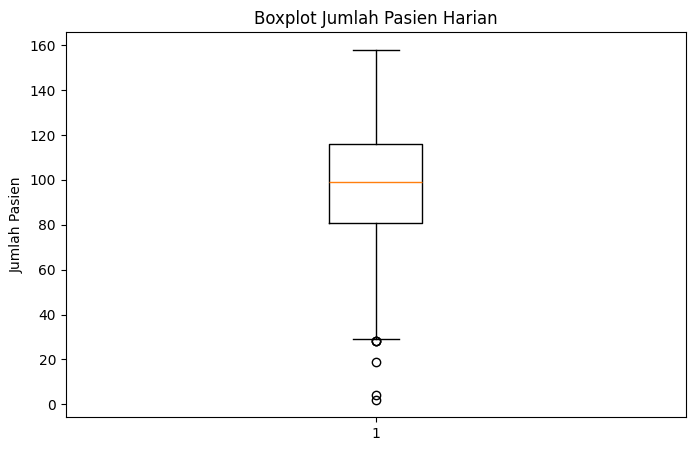

In [35]:
# Membuat boxplot
plt.figure(figsize=(8,5))

plt.boxplot(daily['jumlah_pasien'])

# Judul dan label
plt.title('Boxplot Jumlah Pasien Harian')
plt.ylabel('Jumlah Pasien')

# Tampilkan
plt.show()

In [36]:
Q1 = daily['jumlah_pasien'].quantile(0.25)
Q3 = daily['jumlah_pasien'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier = daily[
    (daily['jumlah_pasien'] < lower_bound) |
    (daily['jumlah_pasien'] > upper_bound)
]

outlier

,tanggal,jumlah_pasien,is_weekend,is_imlek,is_idulfitri,is_idulfitri_sec,is_iduladha,is_waisak,is_natal,is_nyepi,is_libur_nasional,lag_1,lag_7,lag_14,lag_21,lag_30
789,2025-03-30,28,1,0,1,1,0,0,0,1,0,44,75,96,94,119
790,2025-03-31,28,0,0,1,1,0,0,0,1,1,28,77,101,111,105
1146,2026-03-22,28,1,0,1,1,0,0,0,1,1,29,88,68,87,85
1159,2026-04-04,19,1,0,0,0,0,0,0,0,0,30,123,29,86,92
1160,2026-04-05,4,1,0,0,0,0,0,0,0,1,19,119,28,88,82
1161,2026-04-06,2,0,0,0,0,0,0,0,0,0,4,127,36,78,76


In [37]:
daily = daily[
    (daily['jumlah_pasien'] >= lower_bound) &
    (daily['jumlah_pasien'] <= upper_bound)
].copy()

print("Jumlah data setelah menghapus outlier:", len(daily))

Jumlah data setelah menghapus outlier: 1156


4. Integrate Data

In [38]:
print(daily.shape)
daily.head()

(1156, 16)


,tanggal,jumlah_pasien,is_weekend,is_imlek,is_idulfitri,is_idulfitri_sec,is_iduladha,is_waisak,is_natal,is_nyepi,is_libur_nasional,lag_1,lag_7,lag_14,lag_21,lag_30
0,2023-01-31,70,0,0,0,0,0,0,0,0,0,69,91,94,93,13
1,2023-02-01,77,0,0,0,0,0,0,0,0,0,70,69,89,98,37
2,2023-02-02,69,0,0,0,0,0,0,0,0,0,77,68,79,91,62
3,2023-02-03,78,0,0,0,0,0,0,0,0,0,69,71,84,82,74
4,2023-02-04,79,1,0,0,0,0,0,0,0,0,78,57,80,77,86


In [39]:
daily.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1156 entries, 0 to 1158
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   tanggal            1156 non-null   datetime64[ns]
 1   jumlah_pasien      1156 non-null   int64         
 2   is_weekend         1156 non-null   int64         
 3   is_imlek           1156 non-null   int64         
 4   is_idulfitri       1156 non-null   int64         
 5   is_idulfitri_sec   1156 non-null   int64         
 6   is_iduladha        1156 non-null   int64         
 7   is_waisak          1156 non-null   int64         
 8   is_natal           1156 non-null   int64         
 9   is_nyepi           1156 non-null   int64         
 10  is_libur_nasional  1156 non-null   int64         
 11  lag_1              1156 non-null   int64         
 12  lag_7              1156 non-null   int64         
 13  lag_14             1156 non-null   int64         
 14  lag_21       

5. Format Data

In [40]:
df = pd.read_csv('/content/drive/MyDrive/skripsi/prediksi pasien/data_min_30_2.csv')

1. Input and Output

In [41]:
features = [

    'is_weekend',

    'is_imlek',
    'is_idulfitri',
    'is_idulfitri_sec',
    'is_iduladha',
    'is_waisak',
    'is_natal',
    'is_nyepi',

    'is_libur_nasional',

    'lag_1',
    'lag_7',
    'lag_14',
    'lag_21',
    'lag_30',
]

target = 'jumlah_pasien'


X = df[features]
y = df[target]

2. Split Dataset 70:30

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=False, train_size=0.7, test_size=0.3)

In [46]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

print(
    "Train:",
    X_train.index.min(),
    "sampai",
    X_train.index.max()
)

print(
    "Test:",
    X_test.index.min(),
    "sampai",
    X_test.index.max()
)

X_train : (809, 14)
X_test  : (347, 14)
y_train : (809,)
y_test  : (347,)
Train: 0 sampai 808
Test: 809 sampai 1155


In [47]:
MODEL_PATH = "/content/drive/MyDrive/skripsi/prediksi pasien/data_save_preparation/xgboost"

os.makedirs(MODEL_PATH, exist_ok=True)

joblib.dump(X_train, f"{MODEL_PATH}/X_train.pkl")
joblib.dump(X_test, f"{MODEL_PATH}/X_test.pkl")
joblib.dump(y_train, f"{MODEL_PATH}/y_train.pkl")
joblib.dump(y_test, f"{MODEL_PATH}/y_test.pkl")

['/content/drive/MyDrive/skripsi/prediksi pasien/data_save_preparation/xgboost/y_test.pkl']

#D. MODELING

1. Hyperparameter Tuning With Optuna

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
def objective(trial):

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': ['mae', 'rmse'],

        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'max_depth': trial.suggest_int('max_depth', 1, 10),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.001,
            0.3,
            log=True
        ),
        'subsample': trial.suggest_float(
            'subsample',
            0.6,
            1.0
        ),
        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.6,
            1.0
        ),
        'min_child_weight': trial.suggest_int(
            'min_child_weight',
            1,
            10
        ),
        'gamma': trial.suggest_float(
            'gamma',
            0,
            5
        ),
        'reg_alpha': trial.suggest_float(
            'reg_alpha',
            0,
            5
        ),
        'reg_lambda': trial.suggest_float(
            'reg_lambda',
            0.1,
            10
        ),
        'random_state': 42
    }

    rmse_scores = []
    mae_scores = []
    mape_scores = []
    wape_scores = []

    for train_idx, val_idx in tscv.split(X_train):

        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**params)

        model.fit(X_tr, y_tr, verbose=False)

        pred = model.predict(X_val)

        rmse_scores.append(
            np.sqrt(mean_squared_error(y_val, pred))
        )

        mae_scores.append(
            mean_absolute_error(y_val, pred)
        )

        mape_scores.append(
            mean_absolute_percentage_error(y_val, pred) * 100
        )

        wape = (
            np.sum(
                np.abs(y_val - pred)
            )
            /
            np.sum(
                np.abs(y_val)
            )
        ) * 100

        wape_scores.append(wape)

    # Hitung rata-rata metrik

    avg_rmse = np.mean(rmse_scores)
    avg_mae = np.mean(mae_scores)
    avg_mape = np.mean(mape_scores)
    avg_wape = np.mean(wape_scores)

    # Simpan metrik tambahan pada trial
    trial.set_user_attr("MAE", avg_mae)
    trial.set_user_attr("RMSE", avg_rmse)
    trial.set_user_attr("MAPE", avg_mape)
    trial.set_user_attr("WAPE", avg_wape)

    return avg_mae

In [ ]:
study = optuna.create_study(direction='minimize')

start_time = time.time()

study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True
)

end_time = time.time()

optuna_time = end_time - start_time

print(f"Total waktu Optuna: {optuna_time:.2f} detik")
print(f"Total waktu Optuna: {optuna_time/60:.2f} menit")

[I 2026-08-15 10:37:02,742] A new study created in memory with name: no-name-c3a90b63-1197-4e90-af85-7d64c19141be


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-08-15 10:37:03,240] Trial 0 finished with value: 9.910058307647706 and parameters: {'n_estimators': 302, 'max_depth': 2, 'learning_rate': 0.08995709391341655, 'subsample': 0.8833060576768225, 'colsample_bytree': 0.7194928169497405, 'min_child_weight': 1, 'gamma': 4.6402098385806205, 'reg_alpha': 1.7451510866138664, 'reg_lambda': 7.779996185047729}. Best is trial 0 with value: 9.910058307647706.
[I 2026-08-15 10:37:04,503] Trial 1 finished with value: 9.859708881378173 and parameters: {'n_estimators': 450, 'max_depth': 6, 'learning_rate': 0.016605085756539937, 'subsample': 0.6450669151163093, 'colsample_bytree': 0.7987055378379369, 'min_child_weight': 3, 'gamma': 1.8827782780990328, 'reg_alpha': 3.0343657223609437, 'reg_lambda': 2.0336273541475887}. Best is trial 1 with value: 9.859708881378173.
[I 2026-08-15 10:37:05,001] Trial 2 finished with value: 9.896457290649414 and parameters: {'n_estimators': 327, 'max_depth': 2, 'learning_rate': 0.04998302427004762, 'subsample': 0.9738

In [ ]:
best_trial = study.best_trial

print(study.best_params)
print("MAE  :", best_trial.value)
print("RMSE :", best_trial.user_attrs["RMSE"])
print("MAPE :", best_trial.user_attrs["MAPE"])
print("WAPE :", best_trial.user_attrs["WAPE"])

{'n_estimators': 714, 'max_depth': 4, 'learning_rate': 0.00553700985848954, 'subsample': 0.945317206249436, 'colsample_bytree': 0.9394582819392818, 'min_child_weight': 6, 'gamma': 0.18731284306601692, 'reg_alpha': 0.9741396403488632, 'reg_lambda': 0.37200563255644403}
MAE  : 9.462081146240234
RMSE : 12.22690441934161
MAPE : 9.83091652393341
WAPE : 9.490620752244379


In [ ]:
best_params = study.best_params.copy()

best_params.update({
    "objective": "reg:squarederror",
    "eval_metric": ["rmse", 'mae'],
    "random_state": 42
})

all_train_mae = []
all_val_mae = []

2. Training Best Hyperparameter With Time Series Split

In [ ]:
all_train_mae = []
all_val_mae = []

rmse_scores = []
mae_scores = []
mape_scores = []
wape_scores = []
training_times = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    model = xgb.XGBRegressor(**best_params)

    start = time.time()

    model.fit(
        X_tr,
        y_tr,
        eval_set=[
            (X_tr, y_tr),
            (X_val, y_val)
        ],
        verbose=False
    )

    end = time.time()

    elapsed = end - start

    training_times.append(elapsed)

    print(f"Fold {fold} : {elapsed:.2f} detik")

    # =============================
    # Learning Curve
    # =============================
    results = model.evals_result()

    train_mae = results["validation_0"]["mae"]
    val_mae = results["validation_1"]["mae"]

    all_train_mae.append(train_mae)
    all_val_mae.append(val_mae)

    # =============================
    # Prediksi Validation Fold
    # =============================
    pred = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mae = mean_absolute_error(y_val, pred)
    mape = mean_absolute_percentage_error(y_val, pred) * 100

    wape = (
            np.sum(
                np.abs(y_val - pred)
            )
            /
            np.sum(
                np.abs(y_val)
            )
        ) * 100

    rmse_scores.append(rmse)
    mae_scores.append(mae)
    mape_scores.append(mape)
    wape_scores.append(wape)

    print(f"Fold {fold}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MAPE : {mape:.2f}%")
    print(f"WAPE : {wape:.2f}%")
    print("-"*40)

Fold 1 : 0.38 detik
Fold 1
RMSE : 9.0593
MAE  : 7.1397
MAPE : 9.37%
WAPE : 9.21%
----------------------------------------
Fold 2 : 0.44 detik
Fold 2
RMSE : 16.4645
MAE  : 12.1137
MAPE : 12.02%
WAPE : 12.58%
----------------------------------------
Fold 3 : 0.44 detik
Fold 3
RMSE : 13.7310
MAE  : 10.7024
MAPE : 10.21%
WAPE : 9.53%
----------------------------------------
Fold 4 : 0.51 detik
Fold 4
RMSE : 11.6878
MAE  : 9.3574
MAPE : 9.13%
WAPE : 8.84%
----------------------------------------
Fold 5 : 0.50 detik
Fold 5
RMSE : 10.1919
MAE  : 7.9973
MAPE : 8.42%
WAPE : 7.30%
----------------------------------------


In [ ]:
print("\n===== Rata-rata Hasil Cross Validation =====")

print(f"RMSE : {np.mean(rmse_scores):.4f}")
print(f"MAE  : {np.mean(mae_scores):.4f}")
print(f"MAPE : {np.mean(mape_scores):.2f}%")
print(f"WAPE : {np.mean(wape_scores):.2f}%")
print(f"\nRata-rata waktu training : {np.mean(training_times):.2f} detik")


===== Rata-rata Hasil Cross Validation =====
RMSE : 12.2269
MAE  : 9.4621
MAPE : 9.83%
WAPE : 9.49%

Rata-rata waktu training : 0.45 detik


In [ ]:
all_train_mae = np.array(all_train_mae)
all_val_mae = np.array(all_val_mae)
all_train_mae.shape

(5, 714)

In [ ]:
mean_train_mae = all_train_mae.mean(axis=0)
mean_val_mae = all_val_mae.mean(axis=0)

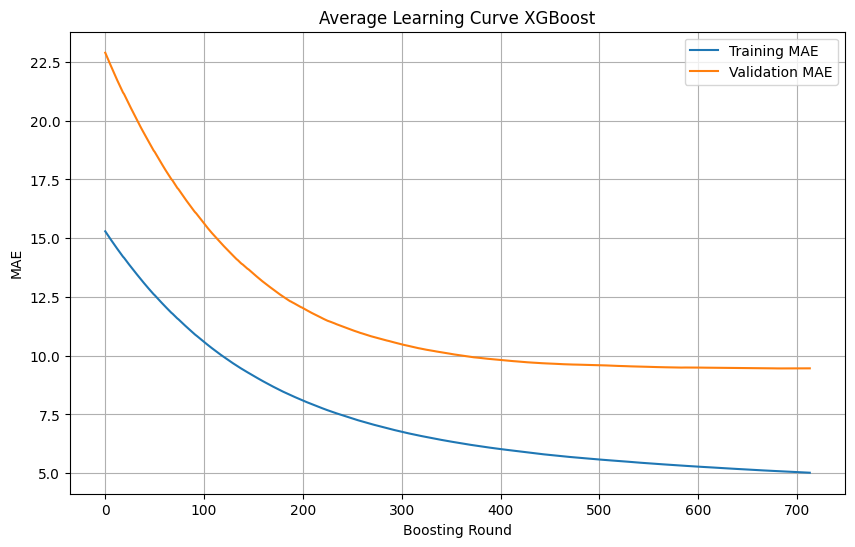

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    mean_train_mae,
    label="Training MAE"
)

plt.plot(
    mean_val_mae,
    label="Validation MAE"
)

plt.xlabel("Boosting Round")
plt.ylabel("MAE")

plt.title("Average Learning Curve XGBoost")

plt.legend()

plt.grid(True)

plt.show()

3. Final Training

In [ ]:
best_params = study.best_params.copy()

best_params.update({
    "objective": "reg:squarederror",
    "eval_metric": "mae",
    "random_state": 42
})

final_model = xgb.XGBRegressor(**best_params)

start = time.time()

final_model.fit(
    X_train,
    y_train,
    verbose=False
)

end_time = time.time()

running_time = end_time - start_time

print(f"Running time: {running_time:.2f} detik")

Running time: 310.97 detik


4. Prediction With Data Test

In [ ]:
start = time.time()

y_pred = final_model.predict(X_test)

end = time.time()

print(f"Waktu prediksi: {end - start:.4f} detik")

Waktu prediksi: 0.0132 detik


5. Asses Model

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mape = mean_absolute_percentage_error(y_test, y_pred)

wape = (
        np.sum(
            np.abs(y_test - y_pred)
        )
        /
        np.sum(
            np.abs(y_pred)
        )
    ) * 100

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape*100:.2f}%")
print(f"WAPE : {wape:.2f}%")

MAE  : 8.0265
RMSE : 10.2098
MAPE : 8.38%
WAPE : 7.69%


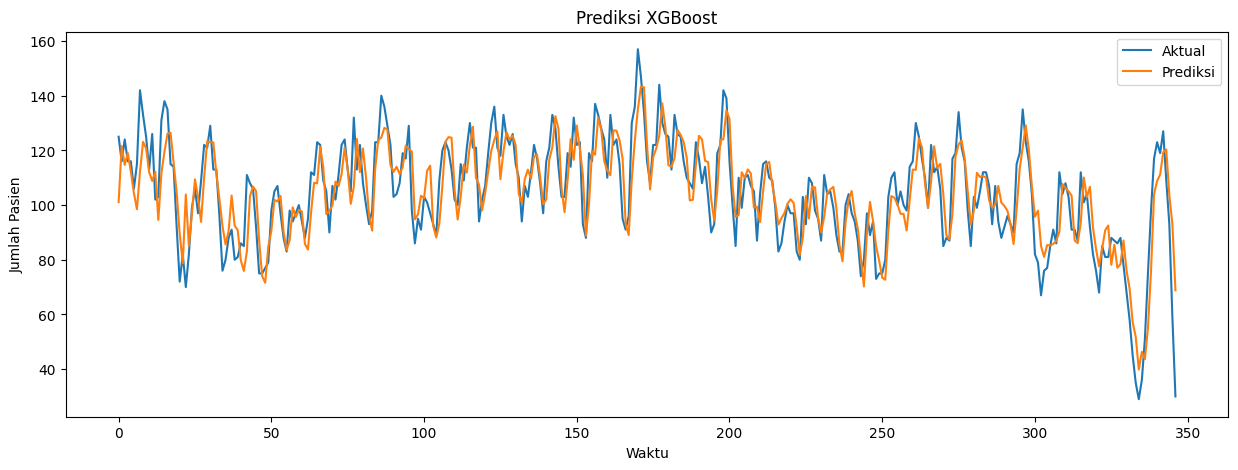

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(y_test.values, label='Aktual')
plt.plot(y_pred, label='Prediksi')

plt.legend()

plt.xlabel("Waktu")
plt.ylabel("Jumlah Pasien")

plt.title("Prediksi XGBoost")

plt.show()

#E. SAVE MODEL

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/skripsi/prediksi pasien/model"

os.makedirs(MODEL_PATH, exist_ok=True)

In [ ]:
model.save_model(
    f"{MODEL_PATH}/xgboost_model.json"
)

In [ ]:
feature_names = X_train.columns.tolist()

with open(f"{MODEL_PATH}/features.json", "w") as f:
    json.dump(feature_names, f, indent=4)